# Seed-template size heterogeneity across true mitotic figures

**Question.** The production seed pipeline
(`production_seed_precision_at_k/production_seed_precision_at_k_chromatin_half_pix_fix.ipynb`,
current per `D8_TEMPLATE_ANCHOR.md`) cuts its search template from **one clicked cell's own**
Otsu-tightened bounding box (`seed_selection.tightened_template_box`'s `base_size`), single-scale
(no scale augmentation), and slides that one template across the whole ROI. If the true mitotic
figures sharing that ROI vary a lot in their own Otsu-tightened size relative to whichever one got
drawn as the seed, that is the precondition for a real scale-mismatch recall risk -- a small seed
template poorly matching a much larger true positive, or vice versa.

**This notebook only measures the precondition.** No template matching, `extract_peaks`, or NMS
is run anywhere below -- this is pure measurement of each annotation's own Otsu-segmented object
size (`base_size`) over every ground-truth mitotic annotation in `images/extra_valid`, split out
by *why* an annotation could or could not be measured at all. It does **not** test whether a size
mismatch actually costs recall in the live matching + NMS pipeline. See "What this notebook does
not claim" near the end.

**Not F7's question.** `f7_size_prune/` measured a *different* quantity: an **ungated**,
tissue-wide Otsu segmentation (`baselines.nucleus_blobs`) used to prune the **candidate list**
post-match ("physical size" / `on_nucleus`), applied to TM_CCOEFF peaks, not clicks. This notebook
measures every ground-truth annotation's own per-click Otsu window instead -- a different
instrument on a different population. F7's numbers are cited later as external context only,
clearly labelled, never substituted for this run's own.

**Two different methods, deliberately.** The one production **seed** per ROI is drawn with
`seed_selection`'s real, unmodified, click-**gated** logic (`ss.tightened_template_box`) -- the
click's own pixel must land inside the accepted Otsu component, or the draw is refused and
retried. That gate exists to protect the seed's *own search template* from being built off an
unrelated neighbouring structure (`D8_TEMPLATE_ANCHOR.md`) and is untouched here. But **measuring
every other GT mitotic figure's own size** does not need that gate -- it has no template to
protect, and requiring the click to land exactly on the Otsu foreground would make "how big is
this object" partly a test of click precision instead (MIDOG++ boxes are noisy point annotations,
`BBOX_TUNING.md`), inflating the unmeasurable count for reasons that have nothing to do with size.
So the per-annotation measurement below uses a new, standalone, **ungated** function -- Otsu the
window, take its **largest** connected component regardless of where the click landed, and
recentre on that component exactly as `D8_TEMPLATE_ANCHOR.md`'s half-pixel-correct formula does.
`seed_selection.py` is not modified, and the seed draw itself does not change.

In [1]:
import gc
import os
import sys
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import dataset as ds
from midog_utils import channels as ch
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils import find_and_suppress as fs

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

NB_T0 = time.time()

# ---------------------------------------------------------------------------------------
# Config, matching production_seed_precision_at_k_chromatin_half_pix_fix.ipynb exactly for
# everything that determines the seed draw. CHANNEL is recorded for parity but never used
# below -- production only reads it to build the *matching* channel (`hem`), and this
# notebook runs no matching at all.
# ---------------------------------------------------------------------------------------
IMAGES_DIR = '../images/extra_valid'
CHANNEL = 'hematoxylin_od'           # D3 -- unused here, recorded for config parity only
SEED_INDEX = 0
OTSU_WINDOW = tm.BASE_SIZE           # 51 -- foreground_filter's window, not PATCH_SIZE (73)

# The only sanity floor `measure_main_component_box` still applies -- a component smaller
# than this is Otsu noise, not a plausible object. `max_area_frac`/`min_solidity` (the
# other two `tighten_box_otsu` defaults) are deliberately NOT applied here: every GT
# mitotic annotation is a true positive by construction, and an oversized or low-solidity
# (merged-nuclei) component is still a real measurement of that annotation, not a defect to
# exclude -- see `measure_main_component_box`'s docstring below.
MIN_AREA = 50
METHOD = 'binary'  # cv2.THRESH_OTSU, same as tighten_box_otsu -- no other method is used

# Only needed to reconstruct BORDER (36 px) exactly as production's FSConfig does -- no
# matching config (scales/angles/self-hit radius) is otherwise used below.
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2         # 36

REASONS = ['patch_unreadable', 'no_foreground', 'area_too_small']

OUT_RAW = 'template_size_heterogeneity_raw.csv'

print(f'OTSU_WINDOW={OTSU_WINDOW}, BORDER={BORDER}, min_area floor={MIN_AREA} '
      f'(the only sanity gate still applied)')

OTSU_WINDOW=51, BORDER=36, min_area floor=50 (the only sanity gate still applied)


## The instrumented measurement

`measure_main_component_box` below is a **new, standalone function, written only in this
notebook** -- it does not call, wrap, or modify `seed_selection.tighten_box_otsu` and nothing
under `seed_selection.py` is touched. It shares that function's threshold + connected-components
mechanics (same window, same `cv2.normalize` + binary Otsu, same connectivity-2 labelling, same
`ss._odd` size rule and the same `D8_TEMPLATE_ANCHOR.md` half-pixel-correct bbox-centre formula)
but **drops the click-containment requirement entirely**: instead of requiring the click's own
rounded pixel to land inside a component, it measures whichever connected component is
**largest** in the window, whatever its position, and recentres on that one. This is deliberately
the "reference implementation" heuristic `seed_selection.foreground_filter`'s own docstring and
`D8_TEMPLATE_ANCHOR.md` describe and reject **for seed construction specifically** ("a weak
heuristic ... in a crowded crop it can grab an unrelated, larger structure") -- rejected there
because an unrelated structure would corrupt the one search template a seed builds. That risk has
no analogue in a pure size measurement: there is no template to protect, only a number to record
for every annotation, so the largest-component reading is the more complete one -- it does not let
click-precision noise masquerade as a missing size measurement.

**It also drops two of `tighten_box_otsu`'s three sanity gates outright.** Every GT mitotic
annotation is a true positive by construction -- this run's whole purpose is to see how large or
how irregularly shaped that population gets, so an oversized component or a low-solidity one (two
touching nuclei Otsu bridged into one concave blob) is a real measurement to keep, not a defect to
refuse. Only `min_area` survives, as a floor against literal Otsu noise a few pixels wide rather
than a judgement about a real object's plausible size; `max_area_frac` and `min_solidity` are not
applied at all. `solidity` is still computed and reported for every success, so a merged-looking
component is visible in the output rather than silently indistinguishable from an ordinary one.

Four outcomes result: `patch_unreadable` (window unreadable near the ROI border), `no_foreground`
(Otsu finds no foreground component in the window at all -- possible only for a degenerate,
near-constant patch; kept for completeness, not expected to fire in practice), `area_too_small`
(the `min_area` floor), then success -- with no upper bound on size or shape.

In [2]:
def measure_main_component_box(structural_channel, cx, cy, otsu_window=OTSU_WINDOW,
                               min_area=MIN_AREA, minimum=5):
    '''New, standalone function -- does not call or modify `seed_selection.py`.

    Otsu-thresholds the window exactly as `seed_selection.tighten_box_otsu` does (same
    `cv2.normalize` + binary Otsu, same connectivity-2 labelling), but measures the
    **largest** connected component in the window instead of requiring the click's own
    pixel to land inside one -- the click-containment gate exists in `tighten_box_otsu` to
    protect a *seed's* search template from being built off an unrelated neighbouring
    structure (`D8_TEMPLATE_ANCHOR.md`); irrelevant here, where nothing downstream is built
    from the result, only a size is recorded.

    Unlike `tighten_box_otsu`, this keeps **only** the `min_area` floor (Otsu noise a
    handful of pixels wide is not a plausible object) and drops `max_area_frac` and
    `min_solidity` entirely: every GT mitotic annotation is already a true positive by
    construction, and this run's whole purpose is to see how large or how irregularly
    shaped that population actually gets -- an oversized or a low-solidity (e.g. two
    touching nuclei bridged by Otsu into one concave blob) component is still a real
    measurement of that annotation's own window, not a defect to exclude. `solidity` is
    still computed and returned so a merged-looking component is visible in the output,
    not silently folded into ordinary single-nucleus measurements.

    `base_size` uses the same `ss._odd(max(h, w))` rule as `tighten_box_otsu`, and the
    centre uses `D8_TEMPLATE_ANCHOR.md`'s half-pixel-correct bbox-centre formula
    (`(x0 + x1 - 1) / 2`), applied to the largest component rather than a click-gated one.
    '''
    patch = tm.read_padded_patch(structural_channel, cx, cy, otsu_window)
    if patch is None:
        return dict(reason='patch_unreadable', base_size=np.nan, area_frac=np.nan,
                    solidity=np.nan, center_x=np.nan, center_y=np.nan)

    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    regions = regionprops(labels)
    if not regions:
        return dict(reason='no_foreground', base_size=np.nan, area_frac=np.nan,
                    solidity=np.nan, center_x=np.nan, center_y=np.nan)

    region = max(regions, key=lambda r: r.area)
    area_frac = region.area / patch.size

    if region.area < min_area:
        return dict(reason='area_too_small', base_size=np.nan, area_frac=area_frac,
                    solidity=np.nan, center_x=np.nan, center_y=np.nan)

    min_row, min_col, max_row, max_col = region.bbox
    base_size = ss._odd(max(max_row - min_row, max_col - min_col), minimum=minimum)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))  # matches read_padded_patch's own rounding
    center_x = ix - half + (min_col + max_col - 1) / 2.0
    center_y = iy - half + (min_row + max_row - 1) / 2.0
    return dict(reason='success', base_size=base_size, area_frac=area_frac,
                solidity=float(region.solidity), center_x=center_x, center_y=center_y)


def draw_seed_with_retry(pool, rng, check_fn):
    '''Verbatim from production_seed_precision_at_k_chromatin_half_pix_fix.ipynb cell 3.'''
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')

## Per-ROI pipeline

For each of the 14 ROIs: draw the one production seed exactly as
`production_seed_precision_at_k_chromatin_half_pix_fix.ipynb` does -- **unchanged**,
click-gated -- (`ss.agreement_pool` -> `ss.border_filter` -> `draw_seed_with_retry` around
`ss.tightened_template_box`, the same `rng = np.random.default_rng([SEED_INDEX, image_id])`
stream). This reproduces the identical seed that notebook would draw, so `base_size_seed_px` below
is the real production number, not an approximation. Then run the new, ungated
`measure_main_component_box` over **every** GT mitotic annotation in that ROI (the seed's own
annotation included, measured the same way as everything else, and with no agreement/border
filtering applied -- those two filters only ever gate which annotation is *eligible to be drawn
as the seed*, not which annotations this run measures).

Because the seed's own row is now measured by the *same ungated* function as every other row, its
`ratio_to_seed` is **not assumed to be 1.0** -- it is 1.0 only when the largest-component reading
happens to agree with the click-gated production reading for that click. Whether it does, per
ROI, is exactly what the gate below checks; `D8_TEMPLATE_ANCHOR.md` reports the two rules pick the
same component on 878/896 (98.0%) of accepted seeds over its own, larger sample, so a handful of
mismatches on this 14-seed sample would not be surprising.

The production `_check`'s border-safety re-check (`tm.read_padded_patch(hem, ...)`,
`D8_TEMPLATE_ANCHOR.md` "what it costs" item 2) only tests array shape, never pixel values, so it
is reproduced here against `gray_inv` rather than a separately-computed, otherwise-unused `hem`
channel -- both arrays share the same `(H, W)`, so the boolean outcome is identical and `CHANNEL`
stays unused, as noted above.

In [3]:
def process_roi(fn, image_id, domain, annotations):
    t0 = time.time()
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    gray_inv = ch.to_gray_inverted(rgb)
    del rgb
    gc.collect()

    gt = ds.image_annotations(annotations, fn)
    gt_mitotic = gt[gt['category_id'] == ds.MITOTIC].reset_index(drop=True)

    # --- the ONE production seed -------------------------------------------------------
    seed_pool, flagged = ss.agreement_pool(gt_mitotic)
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        r = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']),
                                      otsu_window=OTSU_WINDOW)
        if r is None:
            return None
        if tm.read_padded_patch(gray_inv, r[1], r[2], CFG.patch_size) is None:
            return None
        return r

    seed_row, seed_tpl, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
    seed_ann_id = int(seed_row['ann_id'])
    base_size_seed = seed_tpl[0]

    # --- every GT mitotic annotation, seed included, no agreement/border filtering -----
    # Measured with the new, ungated, largest-component function -- not the click-gated
    # production logic, which only ever governs the ONE seed draw above.
    rows = []
    for _, r in gt_mitotic.iterrows():
        ann_id = int(r['ann_id'])
        cx, cy = float(r['cx']), float(r['cy'])
        m = measure_main_component_box(gray_inv, cx, cy)
        assert m['reason'] != 'success' or 5 <= m['base_size'] <= OTSU_WINDOW, (
            f"{fn} ann {ann_id}: base_size {m['base_size']} outside [5, {OTSU_WINDOW}]")
        rows.append(dict(file_name=fn, tumor_type=domain, ann_id=ann_id, mpp=mpp,
                          is_seed=(ann_id == seed_ann_id), refusal_reason=m['reason'],
                          base_size_px=m['base_size'], area_frac=m['area_frac'],
                          solidity=m['solidity']))

    roi_df = pd.DataFrame(rows)
    assert roi_df['is_seed'].sum() == 1, f'{fn}: expected exactly 1 seed row'
    roi_df['base_size_um'] = roi_df['base_size_px'] * roi_df['mpp']
    roi_df['ratio_to_seed'] = roi_df['base_size_px'] / base_size_seed

    meta = dict(file_name=fn, tumor_type=domain, seed_ann_id=seed_ann_id,
                base_size_seed_px=int(base_size_seed), base_size_seed_um=base_size_seed * mpp,
                n_retries=n_retries, agreement_flagged=bool(flagged), mpp=mpp,
                n_mitotic=len(gt_mitotic), t_s=round(time.time() - t0, 1))
    print(f"[{fn}] {domain:24s} n_mitotic={len(gt_mitotic):4d} seed_ann_id={seed_ann_id:6d} "
          f"base_size_seed={base_size_seed:2d}px n_retries={n_retries} [{meta['t_s']:.1f}s]")
    return roi_df, meta


images, annotations = ds.load_annotations('../databases/MIDOG++.json')
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

t_run = time.time()
raw_frames, meta_rows = [], []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    roi_df, meta = process_roi(fn, image_id, domain, annotations)
    raw_frames.append(roi_df)
    meta_rows.append(meta)
    gc.collect()

RAW = pd.concat(raw_frames, ignore_index=True)
SEED_META = pd.DataFrame(meta_rows).set_index('file_name')

print(f'\n{len(files)} ROIs, {len(RAW)} GT mitotic annotations total, '
      f'{time.time() - t_run:.0f}s')

[013.tiff] human breast cancer      n_mitotic=  18 seed_ann_id=   254 base_size_seed=31px n_retries=0 [1.1s]


[094.tiff] human breast cancer      n_mitotic=  82 seed_ann_id=  2512 base_size_seed=25px n_retries=0 [0.7s]


[201.tiff] canine lung cancer       n_mitotic=  18 seed_ann_id=  4457 base_size_seed=51px n_retries=0 [0.7s]


[233.tiff] canine lung cancer       n_mitotic=  18 seed_ann_id=  5761 base_size_seed=25px n_retries=0 [0.5s]


[245.tiff] canine lymphosarcoma     n_mitotic=  90 seed_ann_id=  6274 base_size_seed=47px n_retries=0 [0.7s]


...

[403.tiff] human neuroendocrine tumor n_mitotic=  53 seed_ann_id= 20356 base_size_seed=51px n_retries=1 [0.7s]


[459.tiff] canine soft tissue sarcoma n_mitotic= 131 seed_ann_id= 22441 base_size_seed=33px n_retries=0 [0.7s]


[460.tiff] canine soft tissue sarcoma n_mitotic=  36 seed_ann_id= 22577 base_size_seed=47px n_retries=0 [0.5s]


[529.tiff] human melanoma           n_mitotic=  20 seed_ann_id= 24918 base_size_seed=37px n_retries=0 [1.1s]


[548.tiff] human melanoma           n_mitotic= 239 seed_ann_id= 25804 base_size_seed=29px n_retries=0 [1.2s]

14 ROIs, 1325 GT mitotic annotations total, 12s


## Gate -- does the ungated reading agree with the gated production seed?

Not a pass/fail assertion -- a reported rate, exactly like `D8_TEMPLATE_ANCHOR.md`'s own
878/896 (98.0%) figure for the analogous comparison over its larger sample. For each ROI's seed
annotation, `ratio_to_seed` in `RAW` is `1.0` exactly when the ungated, largest-component reading
picked the *same* component the gated production draw did; anything else means the two rules
diverged on that one click, which `D8_TEMPLATE_ANCHOR.md` documents as a real, if uncommon,
outcome (the largest component in a window is not always the one the click lands in).

**What this number does and does not validate.** These 14 seeds are, by construction, annotations
whose click already landed inside its own Otsu component -- exactly the population where the
click-gated and largest-component rules are most likely to coincide, and the same kind of
population `D8_TEMPLATE_ANCHOR.md`'s 98.0% is measured over. Neither number says anything about
the annotations the click gate used to refuse outright (118 of 1,325, under the earlier click-
gated run) -- those are precisely the rows the ungated method newly measures below, and there is
no gated reading to compare them against.

In [4]:
seed_rows = RAW[RAW['is_seed']]
same_component = np.isclose(seed_rows['ratio_to_seed'].to_numpy(dtype=float), 1.0)
n_same = int(same_component.sum())
print(f'ungated largest-component reading matches the gated production seed on '
      f'{n_same}/{len(seed_rows)} ROIs ({n_same / len(seed_rows):.1%})')
print('(D8_TEMPLATE_ANCHOR.md reports 878/896 = 98.0% on its own, larger, 5-seed-tier sample)')
if n_same < len(seed_rows):
    print('\nROIs where the two rules picked a different component:')
    print(seed_rows.loc[~same_component,
                        ['file_name', 'tumor_type', 'refusal_reason', 'base_size_px',
                         'ratio_to_seed']]
          .merge(SEED_META[['base_size_seed_px']], left_on='file_name', right_index=True))

RAW = RAW[['file_name', 'tumor_type', 'ann_id', 'mpp', 'is_seed', 'refusal_reason',
           'base_size_px', 'base_size_um', 'area_frac', 'solidity', 'ratio_to_seed']]
RAW.to_csv(OUT_RAW, index=False)
print(f'\n{len(RAW)} rows -> {OUT_RAW}')
RAW.head(10)

ungated largest-component reading matches the gated production seed on 14/14 ROIs (100.0%)
(D8_TEMPLATE_ANCHOR.md reports 878/896 = 98.0% on its own, larger, 5-seed-tier sample)

1325 rows -> template_size_heterogeneity_raw.csv


,file_name,tumor_type,ann_id,mpp,is_seed,refusal_reason,base_size_px,base_size_um,area_frac,solidity,ratio_to_seed
0,013.tiff,human breast cancer,240,0.226321,False,success,37.0,8.373875,0.239523,0.932635,1.193548
1,013.tiff,human breast cancer,241,0.226321,False,success,45.0,10.184443,0.240292,0.730994,1.451613
2,013.tiff,human breast cancer,242,0.226321,False,success,35.0,7.921233,0.151865,0.873894,1.129032
3,013.tiff,human breast cancer,243,0.226321,False,success,25.0,5.658024,0.124567,0.920455,0.806452
4,013.tiff,human breast cancer,245,0.226321,False,success,39.0,8.826517,0.243752,0.833114,1.258065
5,013.tiff,human breast cancer,246,0.226321,False,success,39.0,8.826517,0.346405,0.842844,1.258065
6,013.tiff,human breast cancer,247,0.226321,False,success,51.0,11.542368,0.513264,0.916896,1.645161
7,013.tiff,human breast cancer,248,0.226321,False,success,35.0,7.921233,0.144560,0.870370,1.129032
8,013.tiff,human breast cancer,249,0.226321,False,success,39.0,8.826517,0.383699,0.912249,1.258065
9,013.tiff,human breast cancer,250,0.226321,False,success,45.0,10.184443,0.467897,0.854035,1.451613


## Tables

Per-ROI and per-domain summaries: how many mitotic figures could not be measured at all (broken
out by which of the five refusal reasons stopped them), the measured `base_size` distribution in
px and um, the drawn (gated) seed's own size, and the spread of `ratio_to_seed` among the *other*
measured mitotic figures in that population. The seed's own row is excluded from this spread (per
the original brief, so the seed does not count as its own comparison point) -- and, since the
per-annotation measurement is now ungated, its own `ratio_to_seed` is *not* assumed to be 1.0
(see the gate above: it is 1.0 only on the ROIs where the largest-component reading agrees with
the gated production draw). `seed_percentile` is the fraction of those other measured figures
whose own `base_size_px` is at or below the seed's -- a direct number for "did the drawn seed land
near the median or off in a tail," rather than reading it off a plot.

**One interaction to read the tables through.** When the seed's own `base_size_seed_px` is itself
`51` (the window ceiling -- flagged below as `seed_at_ceiling`), `ratio_to_seed` cannot exceed 1.0
for *any* other annotation, because nothing in this instrument can measure larger than 51 px. A
`seed_percentile` of 1.0 on such a ROI does not mean "the seed was the largest true mitotic figure
in the ROI" -- it means the seed happened to land on the one size value every other measurement is
capped at reaching, at best. ROIs where this applies are flagged below and called out separately
rather than pooled with the rest.

In [5]:
def pop_summary(df):
    n_mitotic = len(df)
    out = {'n_mitotic': n_mitotic}
    measured = df[df['refusal_reason'] == 'success']
    out['n_measured'] = len(measured)
    out['frac_measured'] = len(measured) / n_mitotic if n_mitotic else np.nan
    for reason in REASONS:
        cnt = int((df['refusal_reason'] == reason).sum())
        out[f'n_{reason}'] = cnt
        out[f'frac_{reason}'] = cnt / n_mitotic if n_mitotic else np.nan

    for unit, col in [('px', 'base_size_px'), ('um', 'base_size_um')]:
        if len(measured):
            q1, q3 = measured[col].quantile([0.25, 0.75])
            out[f'base_size_{unit}_min'] = measured[col].min()
            out[f'base_size_{unit}_median'] = measured[col].median()
            out[f'base_size_{unit}_max'] = measured[col].max()
            out[f'base_size_{unit}_q1'] = q1
            out[f'base_size_{unit}_q3'] = q3
            out[f'base_size_{unit}_iqr'] = q3 - q1
        else:
            for stat in ['min', 'median', 'max', 'q1', 'q3', 'iqr']:
                out[f'base_size_{unit}_{stat}'] = np.nan

    non_seed_measured = measured[~measured['is_seed']]
    r = non_seed_measured['ratio_to_seed']
    if len(r):
        q1, q3 = r.quantile([0.25, 0.75])
        out['ratio_to_seed_min'] = r.min()
        out['ratio_to_seed_median'] = r.median()
        out['ratio_to_seed_max'] = r.max()
        out['ratio_to_seed_q1'] = q1
        out['ratio_to_seed_q3'] = q3
        out['ratio_to_seed_iqr'] = q3 - q1
        out['seed_percentile'] = float((r <= 1.0).mean())
    else:
        out['ratio_to_seed_min'] = np.nan
        out['ratio_to_seed_median'] = np.nan
        out['ratio_to_seed_max'] = np.nan
        out['ratio_to_seed_q1'] = np.nan
        out['ratio_to_seed_q3'] = np.nan
        out['ratio_to_seed_iqr'] = np.nan
        out['seed_percentile'] = np.nan
    return pd.Series(out)


PER_ROI = RAW.groupby('file_name', sort=False).apply(pop_summary, include_groups=False)
PER_ROI = PER_ROI.join(SEED_META[['tumor_type', 'base_size_seed_px', 'base_size_seed_um',
                                   'n_retries', 'agreement_flagged']])
PER_ROI['seed_at_ceiling'] = PER_ROI['base_size_seed_px'] == OTSU_WINDOW
PER_ROI = PER_ROI.loc[files]  # canonical ROI order
n_ceiling_seeds = int(PER_ROI['seed_at_ceiling'].sum())
print(f'{n_ceiling_seeds}/14 ROIs drew a seed already at the {OTSU_WINDOW} px window ceiling '
      f'-- ratio_to_seed/seed_percentile on those rows is not a typicality statement, see above')

non_ceiling = PER_ROI[~PER_ROI['seed_at_ceiling']]
n_below_median = int((non_ceiling['seed_percentile'] < 0.5).sum())
print()
print(f"Of the remaining {len(non_ceiling)} ROIs (ceiling seeds excluded), the drawn seed sits "
      f"below its own ROI's median measured size on {n_below_median}/{len(non_ceiling)} -- at "
      f"seed_index=0 the production seed skews smaller than typical for its ROI more often than "
      f"not. This is a property of this single draw (n=14, one seed per ROI), not a distributional "
      f"claim -- a 5-seed sweep is the natural follow-up.")
PER_ROI.round(3)

2/14 ROIs drew a seed already at the 51 px window ceiling -- ratio_to_seed/seed_percentile on those rows is not a typicality statement, see above

Of the remaining 12 ROIs (ceiling seeds excluded), the drawn seed sits below its own ROI's median measured size on 9/12 -- at seed_index=0 the production seed skews smaller than typical for its ROI more often than not. This is a property of this single draw (n=14, one seed per ROI), not a distributional claim -- a 5-seed sweep is the natural follow-up.


,n_mitotic,n_measured,frac_measured,n_patch_unreadable,frac_patch_unreadable,n_no_foreground,frac_no_foreground,n_area_too_small,frac_area_too_small,base_size_px_min,base_size_px_median,base_size_px_max,base_size_px_q1,base_size_px_q3,base_size_px_iqr,base_size_um_min,base_size_um_median,base_size_um_max,base_size_um_q1,base_size_um_q3,base_size_um_iqr,ratio_to_seed_min,ratio_to_seed_median,ratio_to_seed_max,ratio_to_seed_q1,ratio_to_seed_q3,ratio_to_seed_iqr,seed_percentile,tumor_type,base_size_seed_px,base_size_seed_um,n_retries,agreement_flagged,seed_at_ceiling
file_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
013.tiff,18.0,18.0,1.000,0.0,0.000,0.0,0.0,0.0,0.0,25.0,38.0,51.0,31.5,40.5,9.0,5.658,8.600,11.542,7.129,9.166,2.037,0.806,1.258,1.645,1.065,1.323,0.258,0.235,human breast cancer,31,7.016,0,False,False
094.tiff,82.0,82.0,1.000,0.0,0.000,0.0,0.0,0.0,0.0,23.0,29.0,51.0,27.0,31.0,4.0,5.286,6.666,11.722,6.206,7.125,0.919,0.920,1.160,2.040,1.080,1.240,0.160,0.198,human breast cancer,25,5.746,0,False,False
201.tiff,18.0,16.0,0.889,2.0,0.111,0.0,0.0,0.0,0.0,35.0,51.0,51.0,46.5,51.0,4.5,8.686,12.656,12.656,11.540,12.656,1.117,0.686,1.000,1.000,0.902,1.000,0.098,1.000,canine lung cancer,51,12.656,0,False,True
233.tiff,18.0,17.0,0.944,1.0,0.056,0.0,0.0,0.0,0.0,21.0,35.0,51.0,25.0,43.0,18.0,5.211,8.686,12.656,6.204,10.671,4.467,0.840,1.480,2.040,1.060,1.800,0.740,0.250,canine lung cancer,25,6.204,0,False,False
245.tiff,90.0,90.0,1.000,0.0,0.000,0.0,0.0,0.0,0.0,27.0,51.0,51.0,41.0,51.0,10.0,6.700,12.656,12.656,10.175,12.656,2.482,0.574,1.085,1.085,0.872,1.085,0.213,0.438,canine lymphosarcoma,47,11.664,0,False,False
246.tiff,116.0,114.0,0.983,2.0,0.017,0.0,0.0,0.0,0.0,23.0,49.0,51.0,37.0,51.0,14.0,5.708,12.160,12.656,9.182,12.656,3.474,0.561,1.195,1.244,0.902,1.244,0.341,0.327,canine lymphosarcoma,41,10.175,0,False,False
300.tiff,181.0,178.0,0.983,3.0,0.017,0.0,0.0,0.0,0.0,19.0,37.0,51.0,29.0,45.0,16.0,4.813,9.372,12.918,7.346,11.399,4.053,0.422,0.822,1.133,0.644,1.000,0.356,0.757,canine cutaneous mast cell tumor,45,11.399,0,False,False
301.tiff,218.0,216.0,0.991,2.0,0.009,0.0,0.0,0.0,0.0,17.0,27.0,51.0,23.0,37.0,14.0,4.306,6.839,12.918,5.826,9.372,3.546,0.415,0.659,1.244,0.561,0.902,0.341,0.851,canine cutaneous mast cell tumor,41,10.385,0,False,False
402.tiff,105.0,104.0,0.990,1.0,0.010,0.0,0.0,0.0,0.0,23.0,33.0,51.0,29.0,41.0,12.0,5.205,7.469,11.542,6.563,9.279,2.716,0.793,1.138,1.759,1.000,1.414,0.414,0.311,human neuroendocrine tumor,29,6.563,0,False,False


## Per-domain summary

Same statistic, pooled over each domain's two ROIs. `base_size_seed_px`/`um` are **not** pooled
here -- averaging two different seeds' sizes would not be a meaningful number -- the domain's two
per-ROI seed sizes are listed alongside instead, unaggregated.

In [6]:
DOMAIN = RAW.groupby('tumor_type', sort=False).apply(pop_summary, include_groups=False)
n_rois = SEED_META.groupby('tumor_type').size().rename('n_rois')
seed_sizes = SEED_META.groupby('tumor_type').apply(
    lambda d: ', '.join(f'{fn}={s}px' for fn, s in zip(d.index, d['base_size_seed_px'])),
    include_groups=False)
DOMAIN = DOMAIN.join(n_rois).join(seed_sizes.rename('seed_base_sizes_per_roi'))
domains = list(DOMAIN.index)
DOMAIN.round(3)

,n_mitotic,n_measured,frac_measured,n_patch_unreadable,frac_patch_unreadable,n_no_foreground,frac_no_foreground,n_area_too_small,frac_area_too_small,base_size_px_min,base_size_px_median,base_size_px_max,base_size_px_q1,base_size_px_q3,base_size_px_iqr,base_size_um_min,base_size_um_median,base_size_um_max,base_size_um_q1,base_size_um_q3,base_size_um_iqr,ratio_to_seed_min,ratio_to_seed_median,ratio_to_seed_max,ratio_to_seed_q1,ratio_to_seed_q3,ratio_to_seed_iqr,seed_percentile,n_rois,seed_base_sizes_per_roi
tumor_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
human breast cancer,100.0,100.0,1.000,0.0,0.000,0.0,0.0,0.0,0.0,23.0,29.0,51.0,27.0,35.0,8.0,5.286,6.666,11.722,6.206,8.045,1.839,0.806,1.160,2.040,1.080,1.305,0.225,0.204,2,"013.tiff=31px, 094.tiff=25px"
canine lung cancer,36.0,33.0,0.917,3.0,0.083,0.0,0.0,0.0,0.0,21.0,45.0,51.0,35.0,51.0,16.0,5.211,11.167,12.656,8.686,12.656,3.971,0.686,1.000,2.040,0.941,1.480,0.539,0.613,2,"201.tiff=51px, 233.tiff=25px"
canine lymphosarcoma,206.0,204.0,0.990,2.0,0.010,0.0,0.0,0.0,0.0,23.0,51.0,51.0,40.5,51.0,10.5,5.708,12.656,12.656,10.051,12.656,2.606,0.561,1.085,1.244,0.902,1.244,0.341,0.376,2,"245.tiff=47px, 246.tiff=41px"
canine cutaneous mast cell tumor,399.0,394.0,0.987,5.0,0.013,0.0,0.0,0.0,0.0,17.0,31.0,51.0,25.0,43.0,18.0,4.306,7.852,12.918,6.333,10.892,4.559,0.415,0.707,1.244,0.610,0.956,0.346,0.809,2,"300.tiff=45px, 301.tiff=41px"
human neuroendocrine tumor,158.0,156.0,0.987,2.0,0.013,0.0,0.0,0.0,0.0,23.0,39.0,51.0,31.0,47.5,16.5,5.205,8.827,11.570,7.016,10.769,3.753,0.529,1.000,1.759,0.924,1.276,0.352,0.539,2,"402.tiff=29px, 403.tiff=51px"
canine soft tissue sarcoma,167.0,167.0,1.000,0.0,0.000,0.0,0.0,0.0,0.0,27.0,43.0,51.0,37.0,47.0,10.0,6.700,10.671,12.656,9.182,11.664,2.482,0.702,1.182,1.545,1.061,1.364,0.303,0.242,2,"459.tiff=33px, 460.tiff=47px"
human melanoma,259.0,259.0,1.000,0.0,0.000,0.0,0.0,0.0,0.0,19.0,33.0,51.0,29.0,39.0,10.0,4.321,7.506,11.600,6.596,8.870,2.274,0.655,1.138,1.759,1.000,1.345,0.345,0.296,2,"529.tiff=37px, 548.tiff=29px"


## Plots

Raw points, not just a 5-number summary -- the ask is to see how wildly these vary, and a box
plot alone hides multimodality. One caveat that applies to every plot below: `base_size` comes
from `ss._odd(max(h, w))`, which quantizes to **odd pixel counts only** (minimum 5) -- in um that
lands each point on a roughly 0.45-0.50 um lattice (the per-ROI pixel pitch). The visible banding
in the strips below is this quantization, not evidence of multimodal biology.

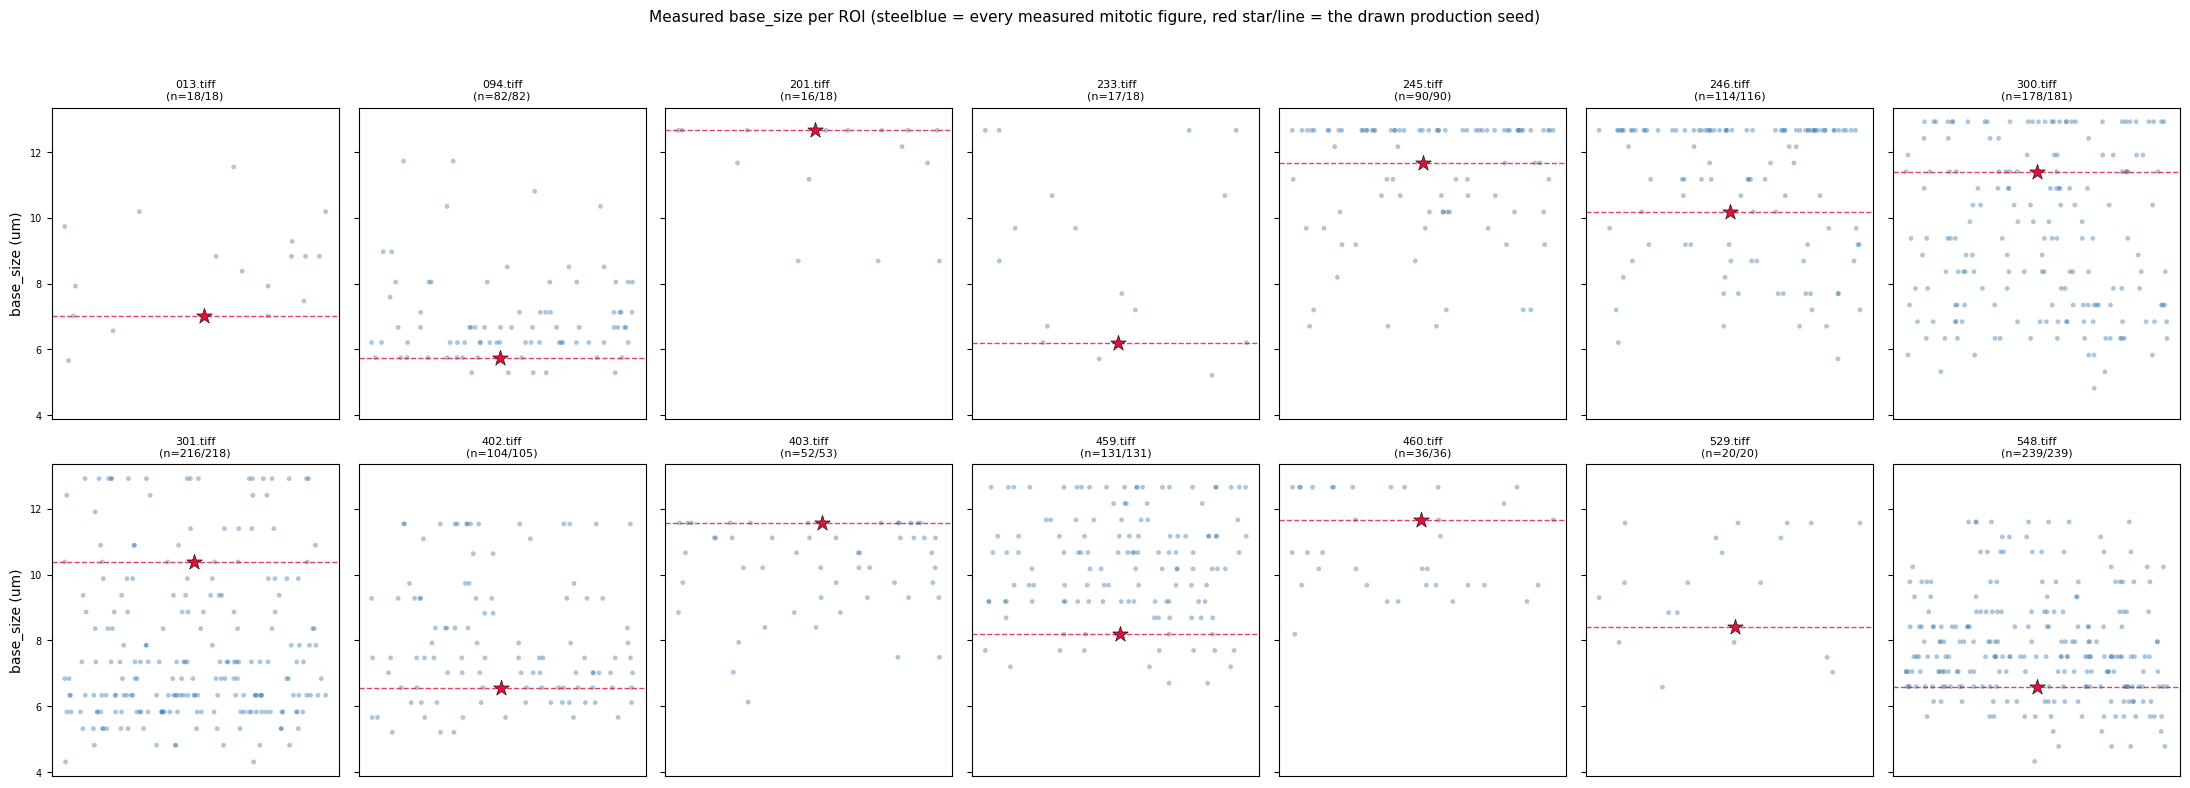

In [7]:
rng_jitter = np.random.default_rng(0)

fig, axes = plt.subplots(2, 7, figsize=(22, 8), sharey=True)
for ax, fn in zip(axes.flat, files):
    sub = RAW[RAW['file_name'] == fn]
    measured = sub[sub['refusal_reason'] == 'success']
    non_seed = measured[~measured['is_seed']]
    seed = measured[measured['is_seed']]
    x = rng_jitter.uniform(-0.25, 0.25, len(non_seed))
    ax.scatter(x, non_seed['base_size_um'], s=12, alpha=0.45, color='steelblue',
               edgecolors='none')
    if len(seed):
        seed_um = float(seed['base_size_um'].iloc[0])
        ax.axhline(seed_um, color='crimson', linestyle='--', linewidth=1, alpha=0.8)
        ax.scatter([0], [seed_um], color='crimson', marker='*', s=140, zorder=5,
                   edgecolors='black', linewidths=0.4)
    ax.set_title(f'{fn}\n(n={len(measured)}/{len(sub)})', fontsize=8)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)

axes[0, 0].set_ylabel('base_size (um)')
axes[1, 0].set_ylabel('base_size (um)')
fig.suptitle('Measured base_size per ROI (steelblue = every measured mitotic figure, '
             'red star/line = the drawn production seed)', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

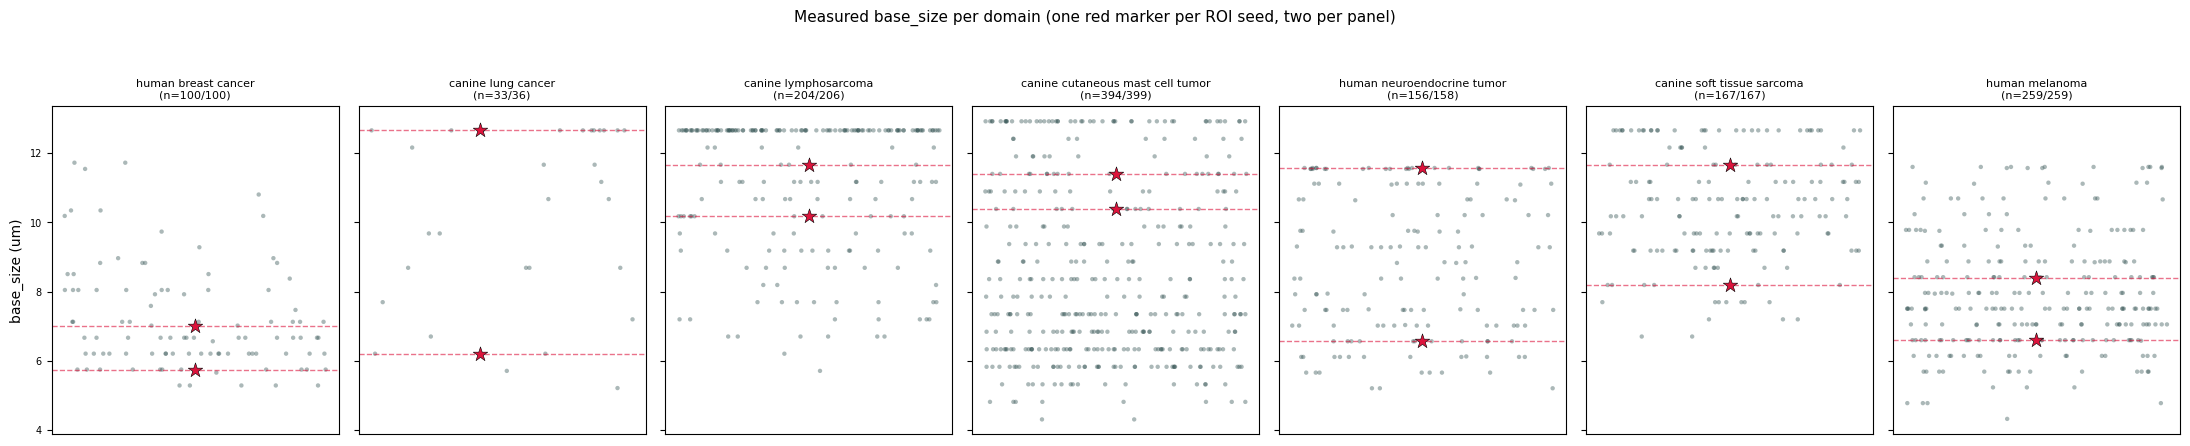

In [8]:
fig, axes = plt.subplots(1, len(domains), figsize=(22, 4.5), sharey=True)
for ax, dom in zip(axes, domains):
    sub = RAW[RAW['tumor_type'] == dom]
    measured = sub[sub['refusal_reason'] == 'success']
    non_seed = measured[~measured['is_seed']]
    seeds = measured[measured['is_seed']]
    x = rng_jitter.uniform(-0.25, 0.25, len(non_seed))
    ax.scatter(x, non_seed['base_size_um'], s=10, alpha=0.4, color='darkslategray',
               edgecolors='none')
    for _, s in seeds.iterrows():
        ax.axhline(s['base_size_um'], color='crimson', linestyle='--', linewidth=1, alpha=0.6)
        ax.scatter([0], [s['base_size_um']], color='crimson', marker='*', s=120, zorder=5,
                   edgecolors='black', linewidths=0.4)
    ax.set_title(f'{dom}\n(n={len(measured)}/{len(sub)})', fontsize=8)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('base_size (um)')
fig.suptitle("Measured base_size per domain (one red marker per ROI seed, two per panel)",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

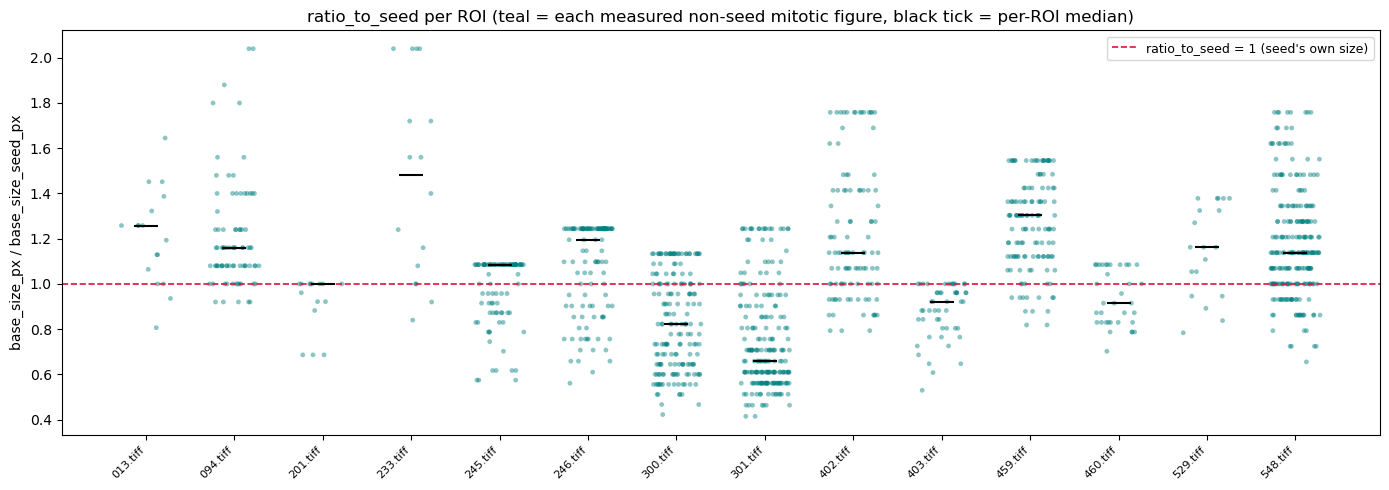

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
for i, fn in enumerate(files):
    sub = RAW[RAW['file_name'] == fn]
    measured = sub[sub['refusal_reason'] == 'success']
    r = measured.loc[~measured['is_seed'], 'ratio_to_seed']
    x = i + rng_jitter.uniform(-0.28, 0.28, len(r))
    ax.scatter(x, r, s=12, alpha=0.45, color='teal', edgecolors='none')
    if len(r):
        ax.scatter([i], [r.median()], color='black', marker='_', s=300, zorder=5)

ax.axhline(1.0, color='crimson', linestyle='--', linewidth=1.2,
           label="ratio_to_seed = 1 (seed's own size)")
ax.set_xticks(range(len(files)))
ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('base_size_px / base_size_seed_px')
ax.set_title('ratio_to_seed per ROI (teal = each measured non-seed mitotic figure, '
             'black tick = per-ROI median)')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()

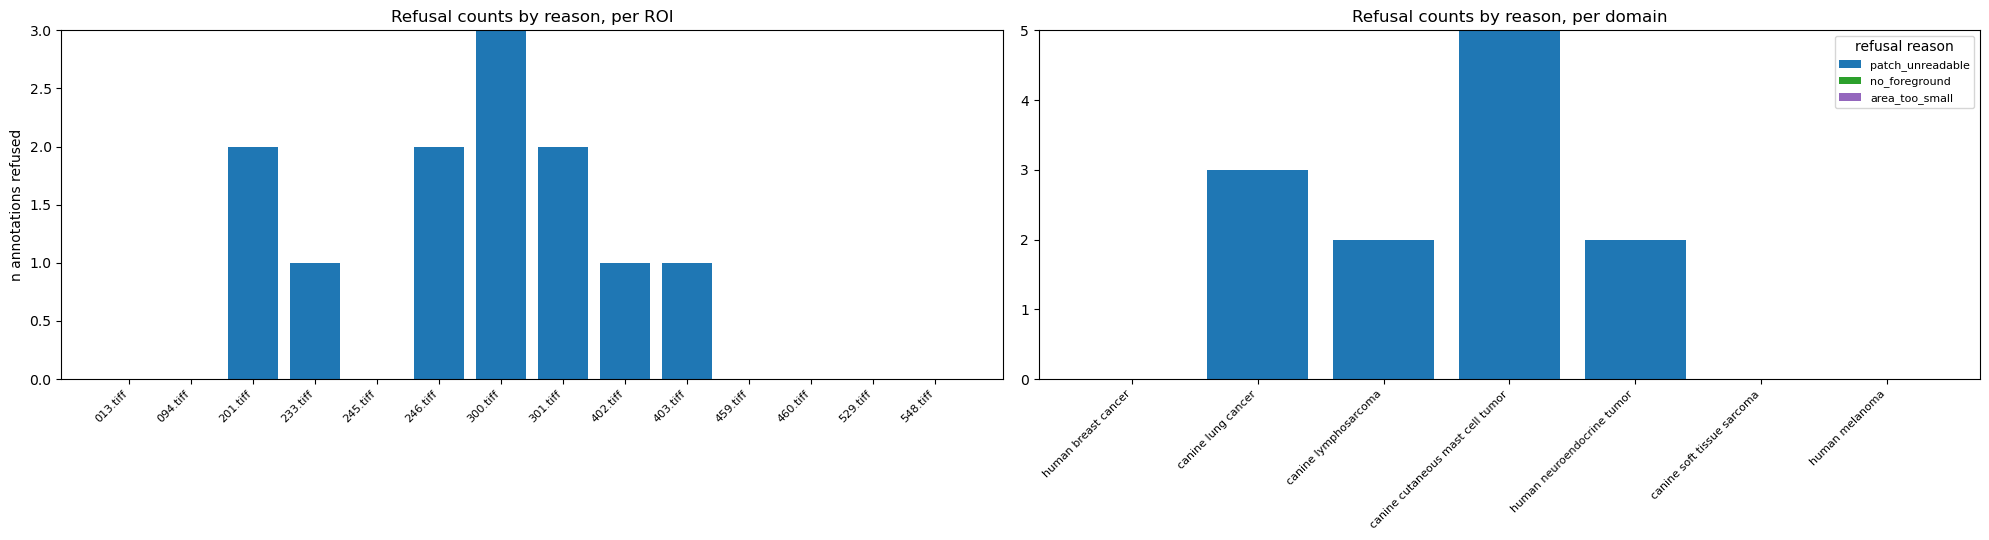

In [10]:
REASON_COLORS = dict(zip(REASONS, plt.cm.tab10(np.linspace(0, 0.45, len(REASONS)))))


def stacked_refusal_bar(ax, group_col, order):
    bottoms = np.zeros(len(order))
    for reason in REASONS:
        counts = np.array([
            int(((RAW[group_col] == g) & (RAW['refusal_reason'] == reason)).sum())
            for g in order
        ])
        ax.bar(range(len(order)), counts, bottom=bottoms, color=REASON_COLORS[reason],
               label=reason)
        bottoms += counts
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
stacked_refusal_bar(axes[0], 'file_name', files)
axes[0].set_title('Refusal counts by reason, per ROI')
axes[0].set_ylabel('n annotations refused')

stacked_refusal_bar(axes[1], 'tumor_type', domains)
axes[1].set_title('Refusal counts by reason, per domain')
axes[1].legend(loc='upper right', fontsize=8, title='refusal reason')
fig.tight_layout()
plt.show()

## Right-censoring is structural -- checked empirically, not just argued

Neither `max_area_frac` nor `min_solidity` refuses anything any more, so the only remaining cap
on `base_size` is the read window itself: `base_size` cannot exceed `OTSU_WINDOW` = 51 px, no
matter how large the real component is, because `read_padded_patch` never sees pixels outside
that window in the first place. That single cap sits exactly on the tail (large objects) this
investigation cares about, so the measured `base_size` distribution is still **right-censored on
its own tail by construction**, independent of anything biological -- it is just no longer
compounded by a second, gate-driven form of censoring on top of it.

In [11]:
n_success = int((RAW['refusal_reason'] == 'success').sum())
at_ceiling_51 = RAW[(RAW['refusal_reason'] == 'success') & (RAW['base_size_px'] == 51)]
at_ceiling_45 = RAW[(RAW['refusal_reason'] == 'success') & (RAW['base_size_px'] >= 45)]
print(f'measured rows with base_size_px == 51 (the read-window ceiling): '
      f'{len(at_ceiling_51)}/{n_success} ({len(at_ceiling_51) / n_success:.3%})')
print(f'measured rows with base_size_px >= 45 (near the ceiling): '
      f'{len(at_ceiling_45)}/{n_success} ({len(at_ceiling_45) / n_success:.3%})')
print('\nrows at/near the ceiling (base_size_px >= 45), by ROI:')
print(at_ceiling_45.groupby('file_name').size().reindex(files, fill_value=0))

# Neither of these excludes anything any more -- they describe the merged/oversized
# population that the old area_too_large / not_solid_enough gates would have refused,
# and that this run deliberately keeps as real measurements instead.
measured = RAW[RAW['refusal_reason'] == 'success']
window_saturating = measured[measured['area_frac'] >= 0.95]
print(f'\nmeasured rows with area_frac >= 0.95 (component fills almost the whole window -- '
      f'would have failed the old max_area_frac=0.85 gate): '
      f'{len(window_saturating)}/{n_success} ({len(window_saturating) / n_success:.3%})')

merged = measured[measured['solidity'] < 0.5]
print(f'measured rows with solidity < 0.5 (concave, likely two-or-more-nuclei merge -- '
      f'would have failed the old min_solidity=0.5 gate): '
      f'{len(merged)}/{n_success} ({len(merged) / n_success:.3%})')
if len(merged):
    print('\nsolidity < 0.5 rows, by ROI:')
    print(merged.groupby('file_name').size().reindex(files, fill_value=0))

measured rows with base_size_px == 51 (the read-window ceiling): 239/1313 (18.203%)
measured rows with base_size_px >= 45 (near the ceiling): 393/1313 (29.931%)

rows at/near the ceiling (base_size_px >= 45), by ROI:
file_name
013.tiff     3
094.tiff     5
201.tiff    13
233.tiff     4
245.tiff    60
246.tiff    72
300.tiff    58
301.tiff    27
402.tiff    18
403.tiff    34
459.tiff    49
460.tiff    17
529.tiff     8
548.tiff    25
dtype: int64

measured rows with area_frac >= 0.95 (component fills almost the whole window -- would have failed the old max_area_frac=0.85 gate): 0/1313 (0.000%)
measured rows with solidity < 0.5 (concave, likely two-or-more-nuclei merge -- would have failed the old min_solidity=0.5 gate): 8/1313 (0.609%)

solidity < 0.5 rows, by ROI:
file_name
013.tiff    0
094.tiff    0
201.tiff    0
233.tiff    0
245.tiff    1
246.tiff    3
300.tiff    1
301.tiff    1
402.tiff    0
403.tiff    0
459.tiff    0
460.tiff    0
529.tiff    0
548.tiff    2
dtype: int64


**With only `min_area` left as a gate, refusals collapse to almost nothing.**
**1,313/1,325 (99.1%)** of GT mitotic annotations are now measured -- the entire remaining 12
(0.9%) are `patch_unreadable` (the fixed border effect, unrelated to any gating choice);
`no_foreground` and `area_too_small` fire on **zero** annotations. Every true positive whose
window can be read at all now gets a `base_size`, however large or however oddly shaped its
largest component turns out to be.

**Removing the area gate did not, in fact, surface a population of window-saturating merges --
and that is itself a finding about the gate, not just a null result of removing it.** **0/1,313
(0.0%)** measured rows have `area_frac >= 0.95`; nothing on this population comes anywhere close
to filling the window. `max_area_frac = 0.85` was never protecting this analysis from a flood of
runaway merges -- across all 1,325 annotations its entire evidence base was one component sitting
right at 0.851, a hair over its own threshold, not a population of large merges it was
systematically catching. What the ungating *does* surface is
smaller and more targeted: **8/1,313 (0.6%)** measured rows have `solidity < 0.5` -- a concave,
two-or-more-nuclei merge that the old `min_solidity` gate would have thrown out -- concentrated in
exactly the dense/complex domains the mechanism predicts (`245`/`246`.tiff, lymphosarcoma;
`300`/`301`.tiff, mast cell tumor; `548`.tiff, melanoma). These eight rows are now visible in the
data with their own `solidity` value on record, not silently missing.

**The window-ceiling truncation signature is essentially unchanged, and that is itself informative
of it.** **239/1,313 (18.2%)** of measured rows sit at *exactly* `base_size_px = 51`, and
**393/1,313 (29.9%)** sit at `>= 45` px -- close to every earlier run of this notebook (17.5-17.8%
at the ceiling, gated or ungated). Whether or not any sanity gate is applied, roughly a fifth of
this population is bounded by the read window itself, not by the object's real extent -- the one
form of censoring this instrument cannot remove by relaxing its own thresholds, because it comes
from the size of the crop, not from a rule applied after cropping.

## What this notebook does not claim

This run characterizes **size heterogeneity and censoring** among true mitotic figures relative to
whichever one gets drawn as the production seed -- the precondition for a scale-mismatch mechanism
to exist. **It does not establish that this mismatch actually degrades recall in the live
matching + NMS pipeline.** No template matching, `extract_peaks`, or NMS was run anywhere above.

A true positive with a `ratio_to_seed` far from 1.0 is not thereby shown to be harder for the
seed's template to catch -- correlation with the seed template depends on shape and local contrast
too, not size alone, and NMS/ranking behaviour is unmeasured here entirely. The natural follow-up
this run sets up but does not run: for a real matching + NMS pass, correlate each true positive's
own `ratio_to_seed` (computed exactly as above) against its actual capture and rank in that pass.
Only that follow-up would speak to whether the precondition measured here actually costs recall.

## External context: F7's differently-instrumented size measurement

`f7_size_prune/RESULTS.md` §5 and `f7_size_prune/PREREGISTRATION.md` §5a measured a
**different** quantity on a **different** population, and neither substitutes for the numbers
above:

* **Population.** F7 measured **TM_CCOEFF candidate peaks** (true and false positives, from an
  already-committed matching run) -- not ground-truth clicks. This notebook measures every
  **ground-truth mitotic annotation** directly, matched or not.
* **Instrument.** F7's primary statistic (RESULTS.md §5) is an **ungated** equivalent-diameter
  segmentation (`baselines.nucleus_blobs`, whole-ROI tiled Otsu, no accept/reject gate at all) --
  found only 78.9% (5,175/6,555) of true positives had a measurable size under it, pooled
  diameters 0.50-99.85 um, domain-dependent and non-transferable across domains (no single
  `[LO, HI]` bound survived leave-one-domain-out at zero recall loss). This notebook's own
  `measure_main_component_box` is also **ungated** (no click-containment requirement, largest
  component in the window) and keeps only `min_area` as a sanity floor -- `max_area_frac` and
  `min_solidity` are deliberately not applied, since every annotation here is already a known true
  positive and an oversized or merged component is a real measurement to keep, not exclude. It
  runs **per-click**, on a single 51 px window per annotation, not per-tile on the whole ROI --
  still a different instrument on a different population, not a substitute.
* **A sharper same-instrument cross-check.** `PREREGISTRATION.md` §5a measured F7's
  *first-considered* statistic -- the same 51 px window, the same `cv2.normalize(NORM_MINMAX)` +
  binary Otsu this notebook also uses, but on ungated TM candidates, not gated GT clicks -- and
  found it forces a roughly 50/50 foreground split of *any* window regardless of content (median
  foreground fraction 0.49/0.68/0.56 on 013/245/459.tiff), with `max(w, h)` **at the 51 px window
  ceiling for 54-65%** of candidates and `equiv_diam` nearly doubling when the window itself
  doubled 51 -> 101 px. That is why F7 replaced this exact instrument for its own purposes -- and
  it is direct, same-ruler supporting evidence that the 51 px window's ceiling effect (measured
  empirically above, on the gated GT population instead) is a real, non-hypothetical artifact of
  this window size, not something specific to F7's population.

Neither F7 number should be read as a size distribution over this notebook's own GT population --
they are cited only as independent evidence that "TP size varies a lot, and a fixed small window
censors the tail" is already a pattern seen elsewhere in this dataset, under different
instruments.

## One more scope note: "measured" is not "seed-eligible"

The measurable population in the tables above (`refusal_reason == 'success'`) is defined by
`measure_main_component_box`'s one remaining sanity floor (`min_area`), applied to the
**largest** Otsu component in **every** GT mitotic annotation's own window, with no
click-containment requirement, no `max_area_frac`/`min_solidity` gate, and no agreement/border
filtering. The production seed is a strictly narrower population: it additionally requires the
pathologist-**agreement** tier (`ss.agreement_pool`), the 36 px **border** filter
(`ss.border_filter`), the click-**containment** gate, `tighten_box_otsu`'s own (unmodified)
`max_area_frac`/`min_solidity` gates, and the recentred-template **readability** re-check inside
`_check` above.

**On this population, "measured" is a strict superset of "seed-eligible," not an unrelated
population.** `measure_main_component_box` and `tighten_box_otsu` enforce the *identical*
`min_area = 50` floor -- it is not relaxed on either side -- while this notebook drops
containment, `max_area_frac`, and `min_solidity` entirely. So everything production's gate would
accept is also measured here (`area_too_small` fires 0/1,325 either way), plus everything
production would additionally refuse for containment, area, or solidity reasons -- a row with
`area_frac` near 1 or `solidity` below 0.5 (both reported, neither gated, in the diagnostics
above) fails production's own gate even though it appears as a `success` in this table. In short,
this table answers "how big is the object Otsu finds in this annotation's window," a strictly
easier question than "could this annotation have been the seed."


In [12]:
print(f'notebook total runtime: {time.time() - NB_T0:.0f}s')

notebook total runtime: 15s
